In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
from functools import reduce

In [35]:
df_env = pd.read_csv('/Users/andydascikid/Downloads/Environmental Dataset.csv')
df_ndti = pd.read_csv('/Users/andydascikid/Python Scripts/Home/Yamuna Water Analysis/CSV Files/NDTI_Interpolated.csv')
df_ndci = pd.read_csv('/Users/andydascikid/Python Scripts/Home//Yamuna Water Analysis/CSV Files/NDCI_Interpolated.csv')

In [36]:
df_env["Date"] = pd.to_datetime(df_env["Date"])
df_env["Date"] = df_env["Date"].dt.strftime("%Y-%m-%d")

df_ndti["Date"] = pd.to_datetime(df_ndti["Date"])
df_ndti["Date"] = df_ndti["Date"].dt.strftime("%Y-%m-%d")

df_ndci["Date"] = pd.to_datetime(df_ndci["Date"])
df_ndci["Date"] = df_ndci["Date"].dt.strftime("%Y-%m-%d")

In [37]:
df_env = df_env[df_env["Date"].between('2020-01-01', '2025-12-20')]
df_ndti = df_ndti[df_ndti["Date"].between('2020-01-01', '2025-12-20')]
df_ndci = df_ndci[df_ndci["Date"].between('2020-01-01', '2025-12-20')]

In [38]:
def stack_csv_columns(file_list, common_column):
    # 1. Read all CSV files into a list of DataFrames
    dfs = file_list

    # 2. Sequentially merge the DataFrames side-by-side on the common column
    # how='outer' ensures no rows are dropped if an ID is missing in one file
    final_df = reduce(
        lambda left, right: pd.merge(
            left, right, on=common_column, how="outer"
        ),
        dfs,
    )
    output_filename = "Compiled DataSet.csv"
    final_df.to_csv(output_filename, index=False)
    print(f"Success! Saved combined files to '{output_filename}'")
    return final_df

csv_files = [df_env, df_ndti, df_ndci]

# Specify the exact name of the column present in all files (e.g., 'ID', 'Date', etc.)
shared_column = "Date"

stack_csv_columns(csv_files, shared_column)

Success! Saved combined files to 'Compiled DataSet.csv'


,Date,Rainfall (mm),Air Temp (Celcius),Wind Speed (m/s),Relative Humidity (%),Solar Radiation (MJ/m2),Water Surface Temp (C),mean_NDTI,mean_NDCI
0,2020-01-01,0.000000,10.620942,1.809638,72.977856,13395416.00,14.042350,-0.02891,0.07160
1,2020-01-02,0.000000,14.049093,2.256785,74.385434,13285615.50,16.353560,-0.02869,0.07220
2,2020-01-03,2.208222,14.430825,0.508545,75.774544,12764878.25,17.218774,-0.02846,0.07280
3,2020-01-04,0.000000,13.751288,1.296588,73.477940,12650305.75,17.336042,-0.02823,0.07340
4,2020-01-05,0.000000,14.167369,2.172828,68.969071,14080280.75,17.453310,-0.02800,0.07400
...,...,...,...,...,...,...,...,...,...
2176,2025-12-16,0.000000,16.567571,3.223076,68.243159,14250022.50,16.564957,0.50200,-0.06300
2177,2025-12-17,0.000000,16.307450,2.716081,68.219267,14194777.75,17.717978,0.43288,-0.05412
2178,2025-12-18,0.000000,15.285533,1.788904,77.905019,13342228.50,16.282916,0.36375,-0.04525
2179,2025-12-19,0.000000,15.250582,2.332101,71.995010,13890053.75,14.847853,0.29462,-0.03637


In [39]:
dataset = stack_csv_columns(csv_files, shared_column)

Success! Saved combined files to 'Compiled DataSet.csv'


In [47]:
def scatter_plt_yearly(csv_path, date_col, column):
    # 1. Load the dataset
    df = csv_path

    # 2. Convert date column to datetime and extract the actual year
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df[date_col].dt.year

    # 3. Align all dates to a common year (e.g., 2000) to strip the calendar year
    # We use 2000 because it's a leap year and safely includes February 29th
    df["Common_Date"] = df[date_col].apply(lambda d: d.replace(year=2000))

    # 4. Initialize the plot
    plt.figure(figsize=(12, 7))

    # Get a sorted list of unique years in the dataset
    unique_years = sorted(df["Year"].unique())

    # 5. Group by year, calculate statistics, and plot
    for year in unique_years:
        year_data = df[df["Year"] == year]

        # Compute mean and standard deviation statistics
        mean_val = year_data[column].mean()
        std_val = year_data[column].std()

        # Format the legend text to include the calculated statistics
        legend_label = f"{year} (Mean: {mean_val:.2f}, Std Dev: {std_val:.2f})"    

        # Plot each year as a separate scatter layer
        plt.scatter(
            year_data["Common_Date"],
            year_data[column],
            label=legend_label,
            alpha=0.6,
            s=20,  # Size of the scatter points
        )

    if column == 'Rainfall (mm)':
            y_axis = 'Rainfall (mm)'
        
    elif column == 'Air Temp (Celcius)':
            y_axis = r'Air Temperature $\circ C$'

    elif column == 'Wind Speed (m/s)':
            y_axis = 'Wind Speed (m/s)'

    elif column == 'Relative Humidity (%)':
            y_axis = 'Relative Humidity (%)'

    elif column == 'Solar Radiation (MJ/m2)':
            y_axis = r'Solar Radiation $(MJ/m^2)$'

    elif column == 'Water Surface Temp (C)':
            y_axis = r'Water Surface Temp $(\circ C)$'

    elif column == 'mean_NDTI':
            y_axis = 'NDTI'
            
    elif column == 'mean_NDCI':
            y_axis = 'NDCI'

    # 6. Format the X-axis to only display the Month and Day
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.gca().xaxis.set_major_locator(
        mdates.MonthLocator()
    )  # Puts a tick mark at the start of each month

    # 7. Add titles, labels, and customize design
    plt.title(f"Year-wise Variation of {y_axis}", fontsize=14, pad=15)
    plt.xlabel("Date (Month-Day)", fontsize=12)
    plt.ylabel(f"{y_axis}", fontsize=12)
    plt.xticks(rotation=45)

    # Position the legend cleanly outside or to the top-right of the plot area
    plt.legend(
        title="Yearly Statistics", bbox_to_anchor=(1.05, 1), loc="upper left"
    )

    # Adjust layout to make room for the legend and rotated X-ticks
    plt.tight_layout()

    # 8. Save or show the plot
    plt.show()



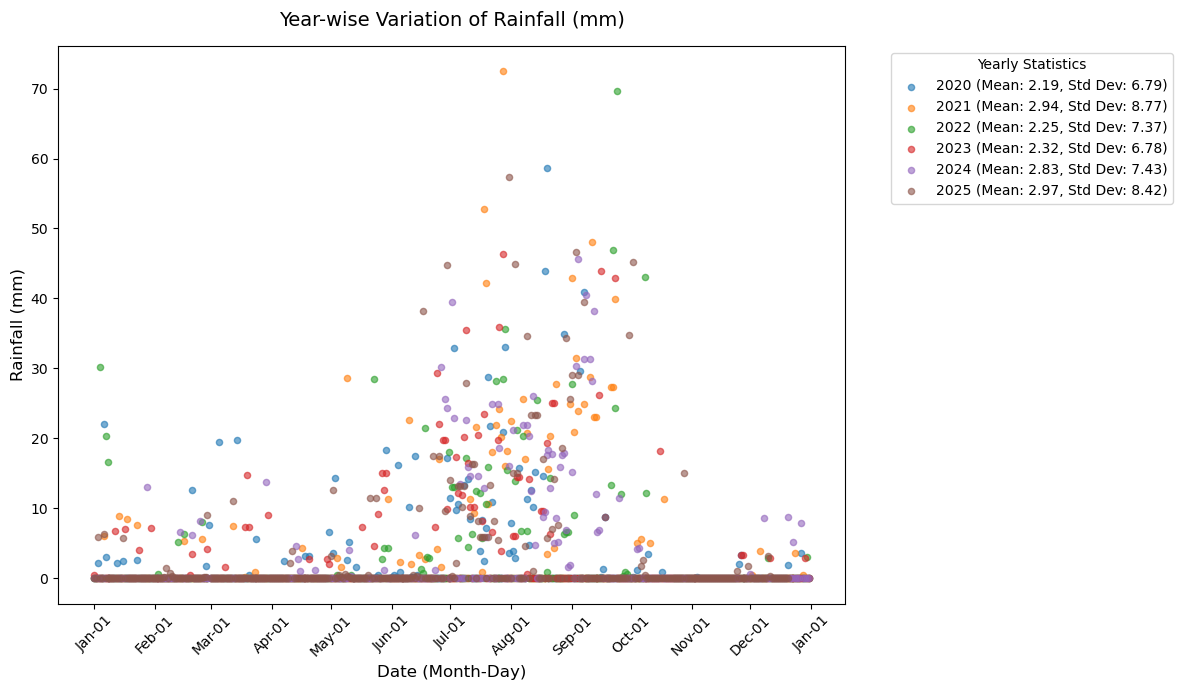

In [48]:
scatter_plt_yearly(dataset, 'Date', 'Rainfall (mm)')

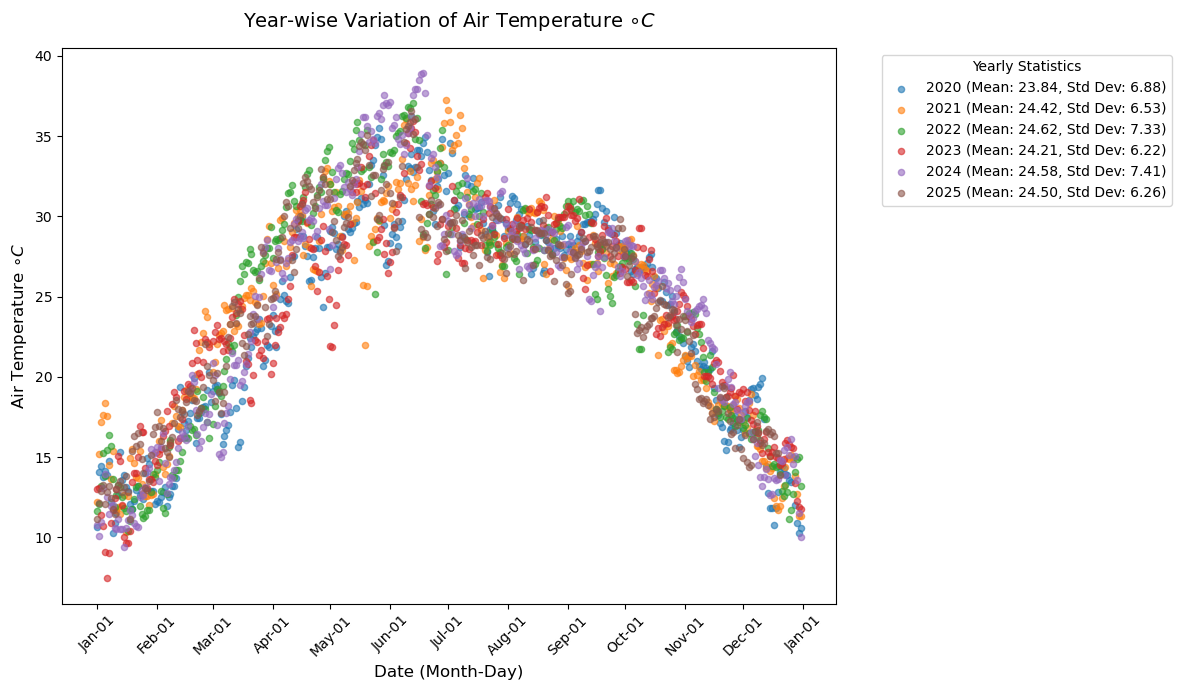

In [49]:
scatter_plt_yearly(dataset, 'Date', 'Air Temp (Celcius)')

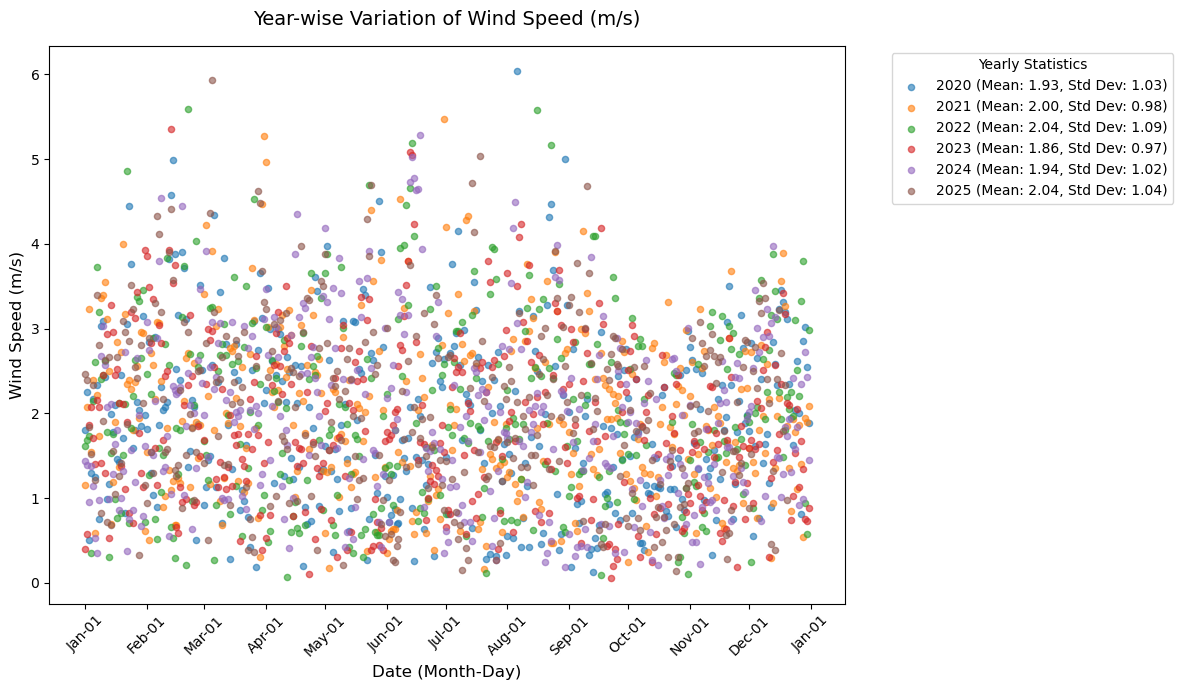

In [50]:
scatter_plt_yearly(dataset, 'Date', 'Wind Speed (m/s)')

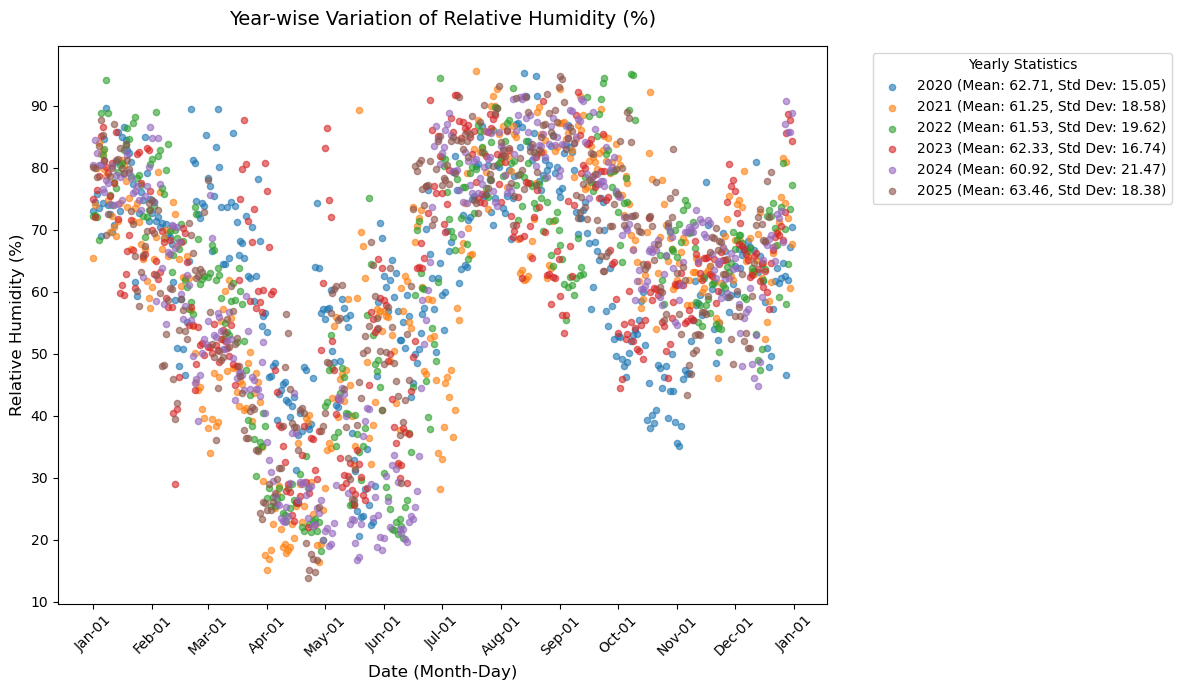

In [51]:
scatter_plt_yearly(dataset, 'Date', 'Relative Humidity (%)')

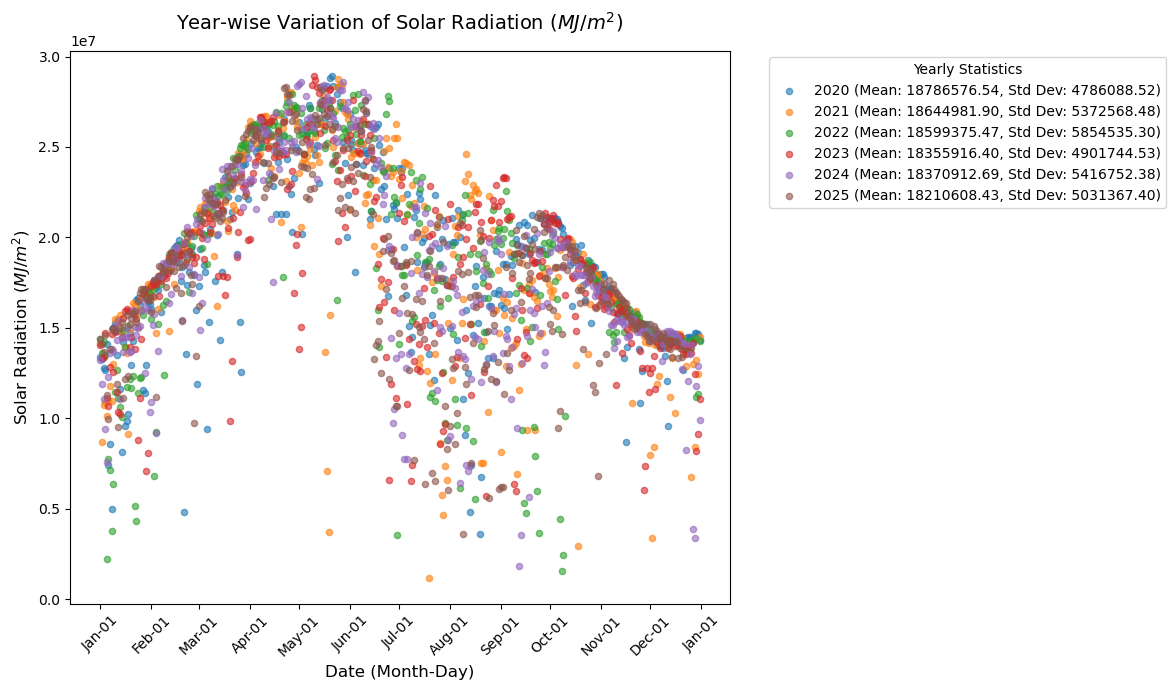

In [52]:
scatter_plt_yearly(dataset, 'Date', 'Solar Radiation (MJ/m2)')

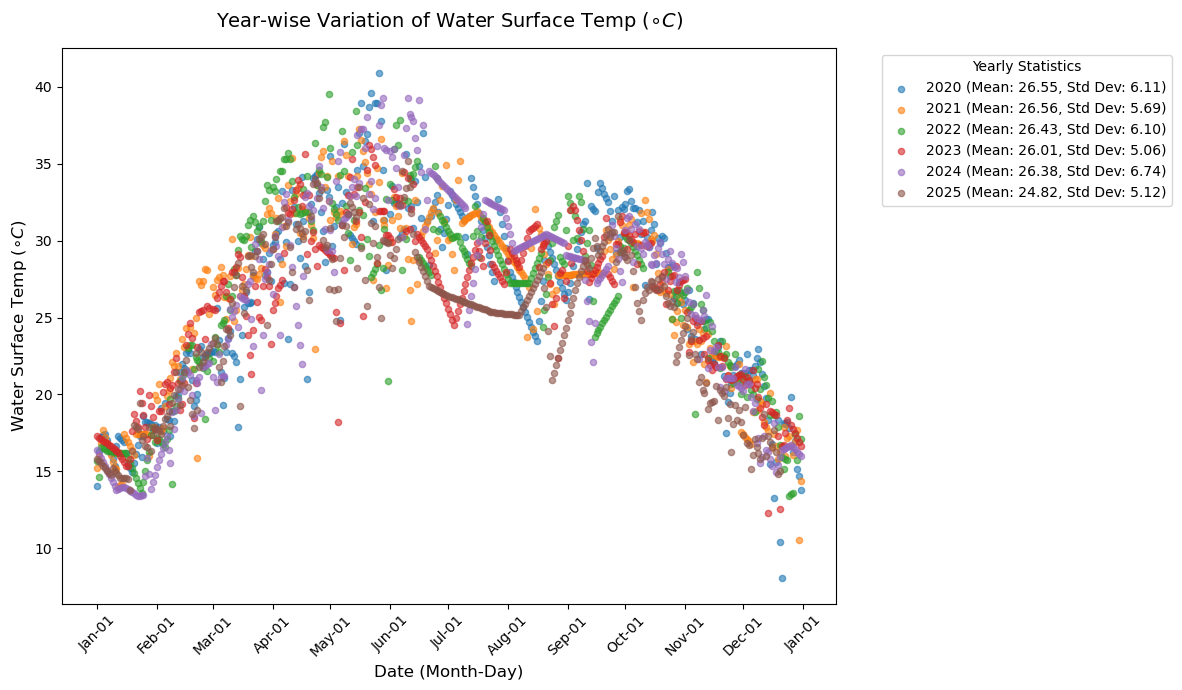

In [53]:
scatter_plt_yearly(dataset, 'Date', 'Water Surface Temp (C)')

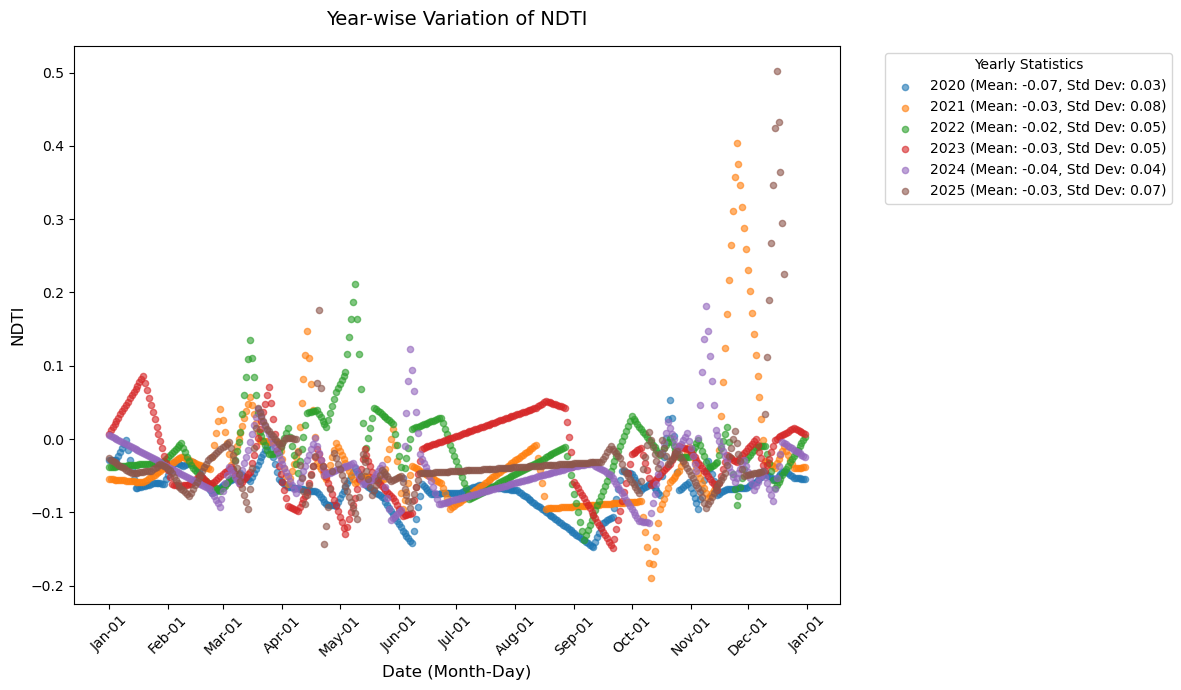

In [54]:
scatter_plt_yearly(dataset, 'Date', 'mean_NDTI')

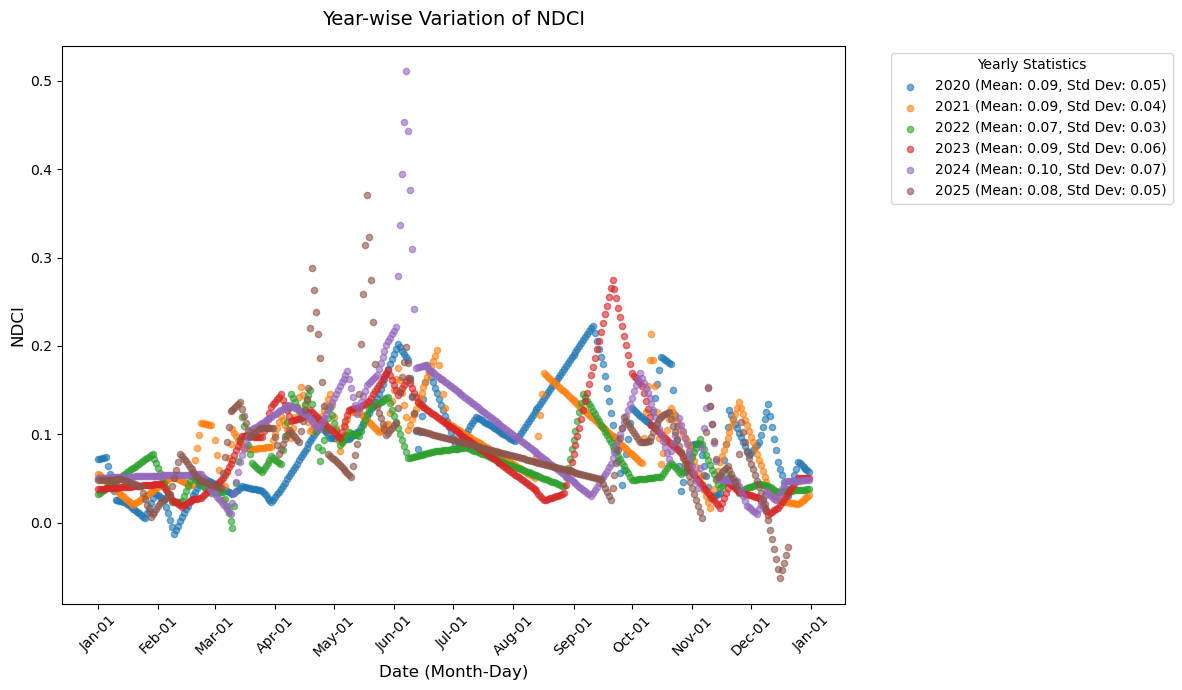

In [55]:
scatter_plt_yearly(dataset, 'Date', 'mean_NDCI')

In [57]:
def box_plt_yearly(csv_path, date_col, column):
    # 1. Load data and extract Year
    df = csv_path
    df[date_col] = pd.to_datetime(df[date_col])
    df["Year"] = df[date_col].dt.year

    unique_years = sorted(df["Year"].unique())
    bxp_stats = []
    stats_summary = []

    # 2. Mathematically compute the boxplot components for each year
    for year in unique_years:
        data = df[df["Year"] == year][column].dropna().values

        if len(data) == 0:
            continue

        # Calculate Quartiles, Median, and IQR
        q1= np.percentile(data, 25)
        median = np.percentile(data, 50)
        q3 = np.percentile(data, 75)
        iqr = q3 - q1

        # Determine structural Whiskers (1.5 * IQR rule)
        lower_whisker = np.compress(data >= q1 - 1.5 * iqr, data).min()
        upper_whisker = np.compress(data <= q3 + 1.5 * iqr, data).max()

        # Identify Outliers (points outside the whiskers)
        outliers = data[(data < lower_whisker) | (data > upper_whisker)]

        # Store statistics structure for matplotlib's bxp
        bxp_stats.append(
            {
                "label": str(year),
                "med": median,
                "q1": q1,
                "q3": q3,
                "whislo": lower_whisker,
                "whishi": upper_whisker,
                "fliers": outliers,
            }
        )

        # Track basic metrics for text report
        stats_summary.append(
            f"{year}: μ={data.mean():.1f}, σ={data.std():.1f}"
        )

    if column == 'Rainfall (mm)':
            y_axis = 'Rainfall (mm)'
        
    elif column == 'Air Temp (Celcius)':
            y_axis = r'Air Temperature $\circ C$'

    elif column == 'Wind Speed (m/s)':
            y_axis = 'Wind Speed (m/s)'

    elif column == 'Relative Humidity (%)':
            y_axis = 'Relative Humidity (%)'

    elif column == 'Solar Radiation (MJ/m2)':
            y_axis = 'Solar Radiation (MJ/m2)'

    elif column == 'Water Surface Temp (C)':
            y_axis = r'Water Surface Temp $(\circ C)$'

    elif column == 'mean_NDTI':
            y_axis = 'NDTI'
            
    elif column == 'mean_NDCI':
            y_axis = 'NDCI'

    # 3. Draw the structural Boxplot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Pass precomputed statistics directly to bxp
    box_plots = ax.bxp(
        bxp_stats,
        showfliers=True,  # Keeps outliers mapped as points
        patch_artist=True,  # Color fills the boxes
        boxprops=dict(facecolor="#8da0cb", color="#4d4d4d", linewidth=1.5),
        whiskerprops=dict(color="#4d4d4d", linewidth=1.5, linestyle="--"),
        capprops=dict(color="#4d4d4d", linewidth=1.5),
        medianprops=dict(color="#e78ac3", linewidth=2.5),  # Prominent median line
        flierprops=dict(
            marker="o", markerfacecolor="#fc8d62", alpha=0.6, markersize=5
        ),
    )

    # 4. Final Formatting
    ax.set_title(f"Year-wise {y_axis} (Boxplot)", fontsize=14, pad=15)
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel(f"{y_axis}", fontsize=12)
    ax.grid(axis="y", linestyle=":", alpha=0.6)

    # Display statistics box on the side
    plt.gca().text(
        1.02,
        0.95,
        "\n".join(stats_summary),
        transform=plt.gca().transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.5",
            facecolor="white",
            edgecolor="gray",
            alpha=0.8,
        ),
    )

    plt.tight_layout()
    plt.show()




/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


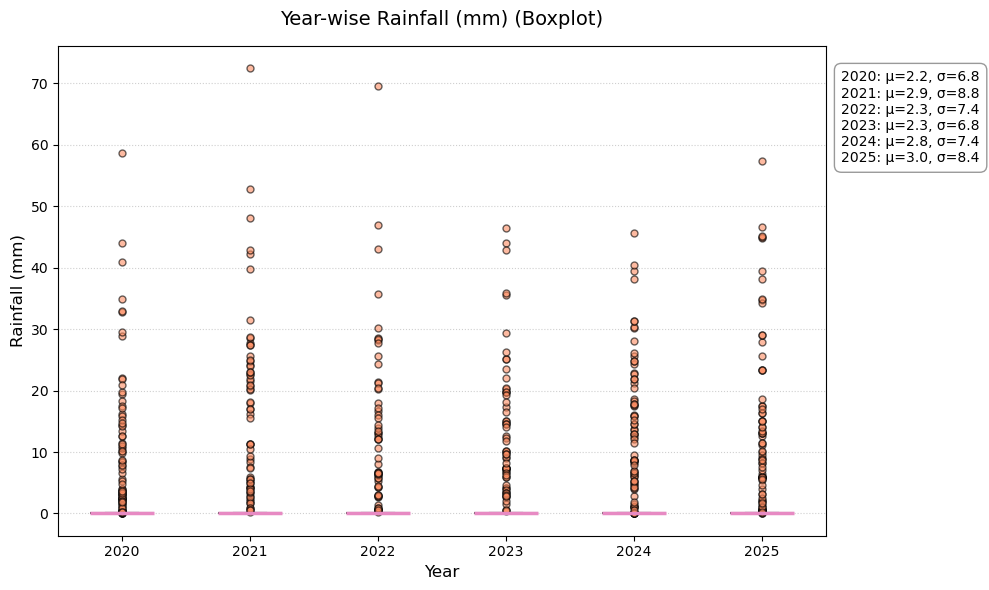

In [58]:
box_plt_yearly(dataset, 'Date', 'Rainfall (mm)')

/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


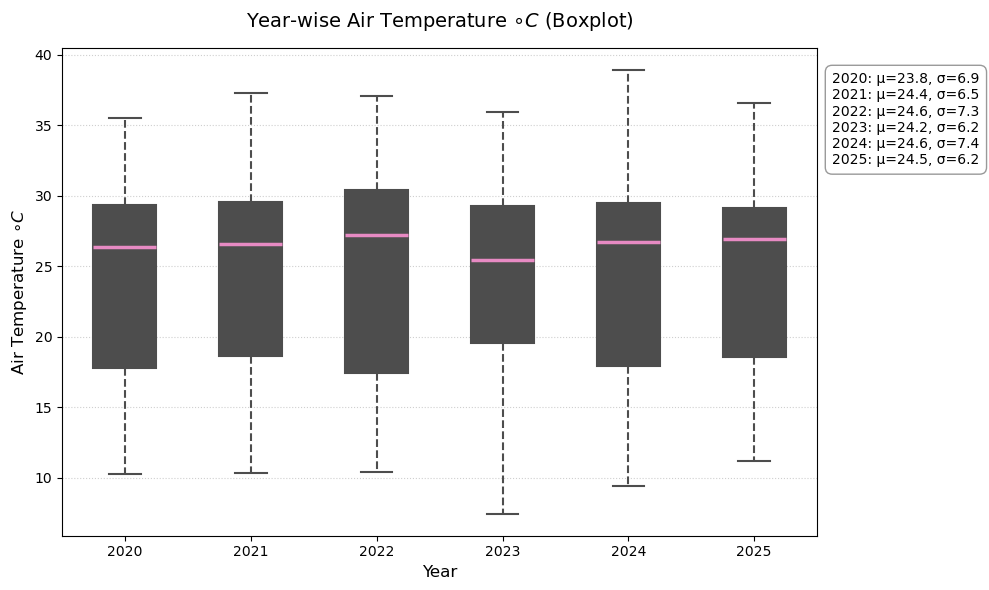

In [59]:
box_plt_yearly(dataset, 'Date', 'Air Temp (Celcius)')

/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


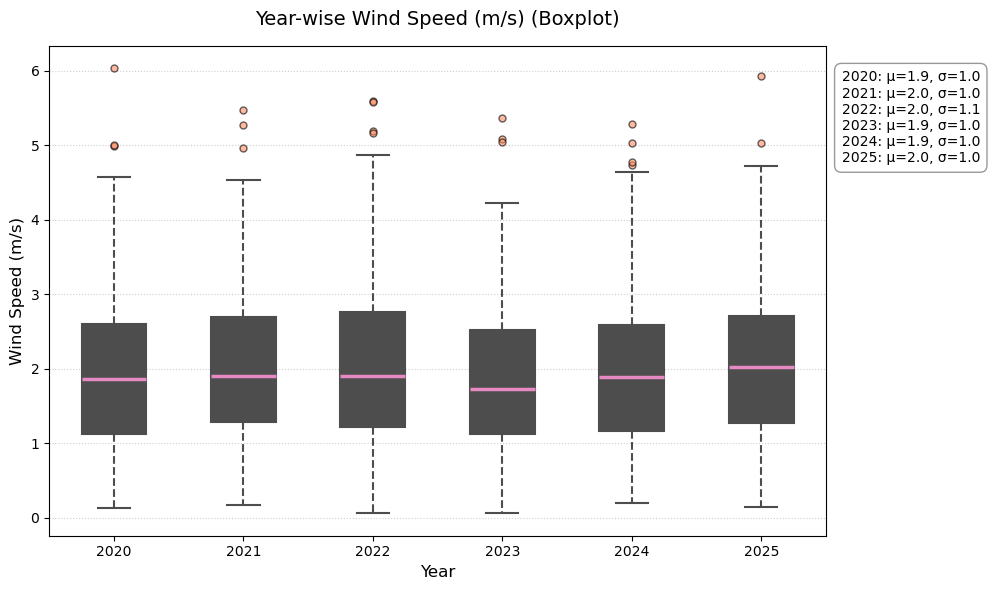

In [60]:
box_plt_yearly(dataset, 'Date', 'Wind Speed (m/s)')

/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


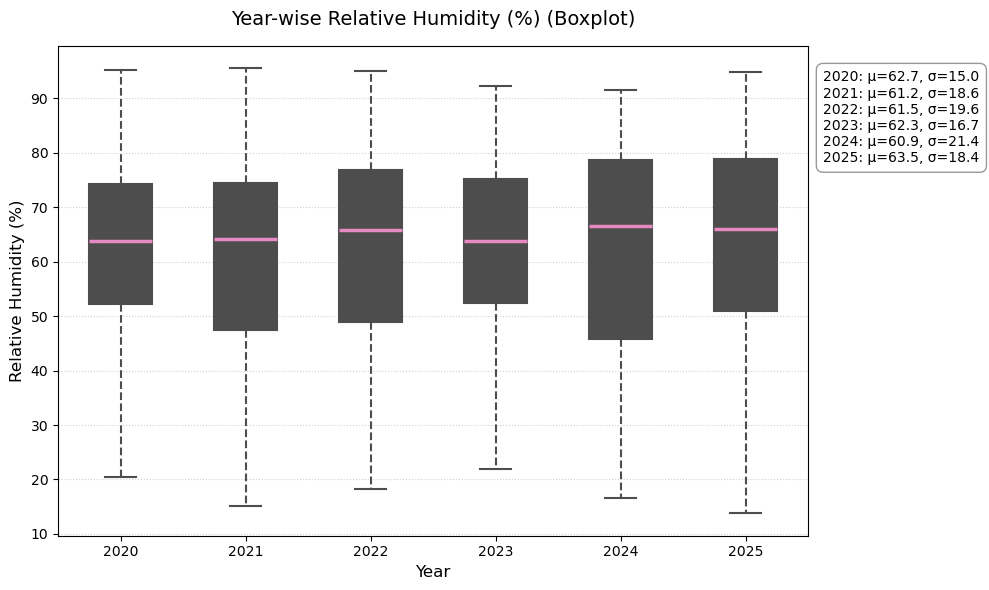

In [61]:
box_plt_yearly(dataset, 'Date', 'Relative Humidity (%)')

/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


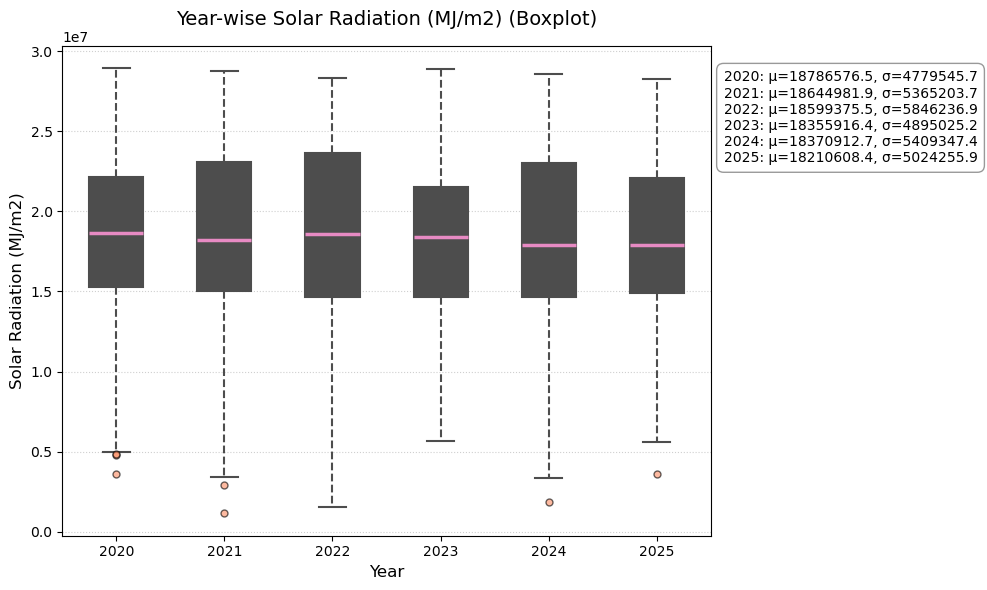

In [62]:
box_plt_yearly(dataset, 'Date', 'Solar Radiation (MJ/m2)')

/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


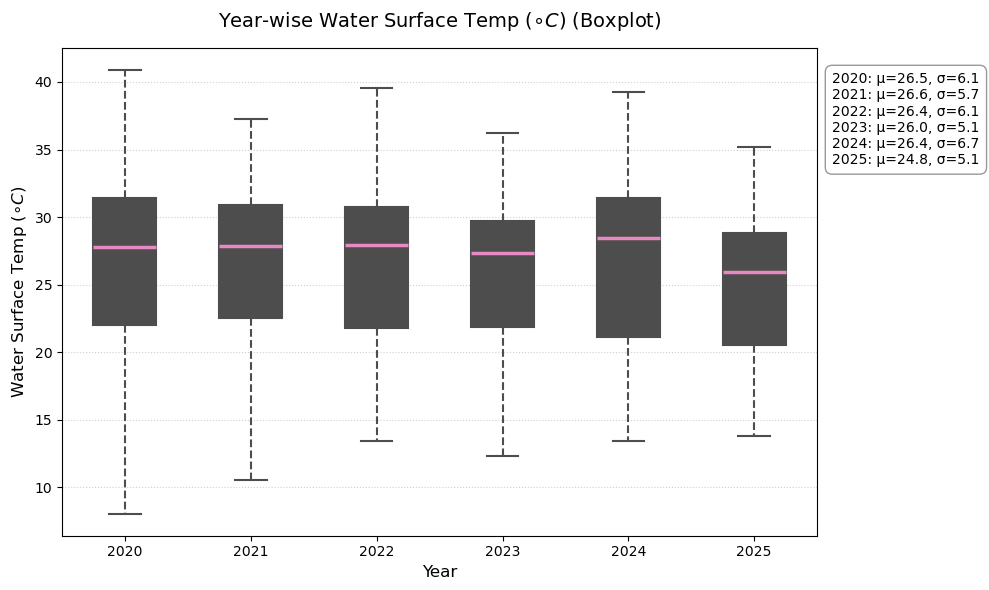

In [63]:
box_plt_yearly(dataset, 'Date', 'Water Surface Temp (C)')

/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


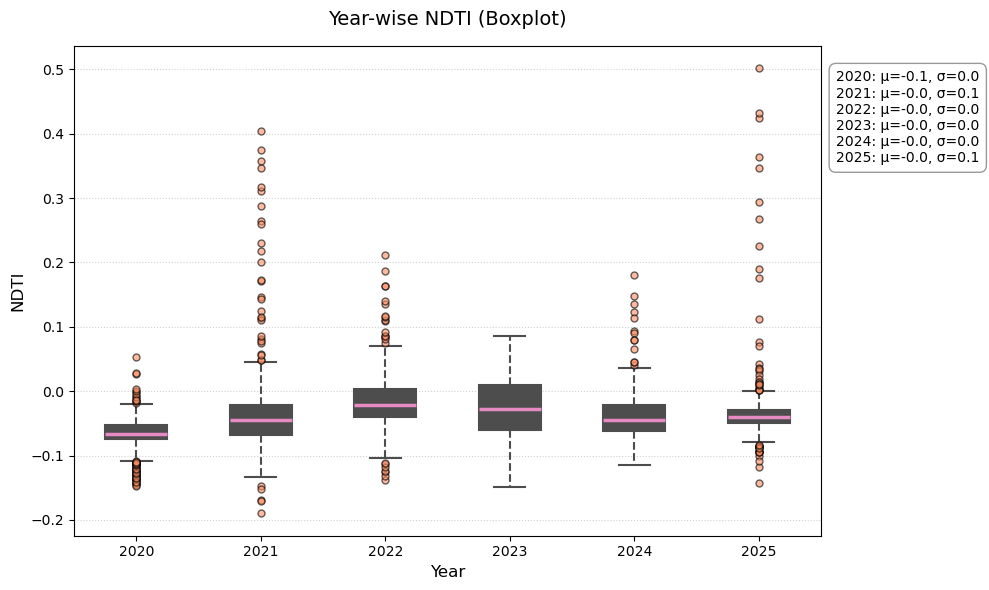

In [64]:
box_plt_yearly(dataset, 'Date', 'mean_NDTI')

/var/folders/yc/txv_08sn4s96d_qr1dydxfnm0000gn/T/ipykernel_37043/1110386428.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  box_plots = ax.bxp(


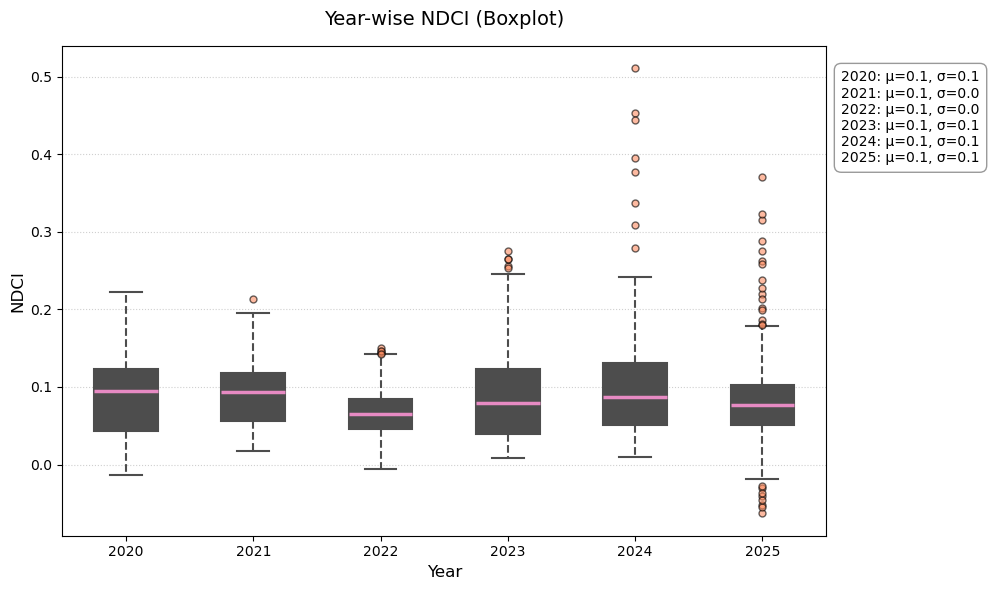

In [65]:
box_plt_yearly(dataset, 'Date', 'mean_NDCI')